In [2]:
import os
import numpy as np
import torch

# Import the classes/functions from your data_loader module
from data_loader import PreprocessedSnowfallDataset, create_preprocessed_dataloader

def extract_snowfall_profiles(hdf5_file_path, batch_size=32, device='cpu'):
    """
    Extracts the snowfall profiles (2D) from a preprocessed HDF5 dataset.
    
    :param hdf5_file_path: Path to the preprocessed HDF5 file
    :param batch_size: Batch size to use for loading
    :param device: 'cpu' or 'cuda' for where to place the data
    :return: A 2D NumPy array of shape (num_samples, seq_len) containing snowfall rates
    """
    # Create a DataLoader for the dataset
    dataloader = create_preprocessed_dataloader(
        hdf5_file_path=hdf5_file_path,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    snowfall_profiles_list = []

    # Iterate over batches
    for batch in dataloader:
        # batch is a tuple: (input_features, target_labels, attention_mask, footprint_attributes)
        input_features, _, _, _ = batch

        # Move data to the specified device
        input_features = input_features.to(device)

        # Assuming snowfall rate is in channel 0, extract it:
        # input_features has shape (B, seq_len, num_features)
        snowfall_batch = input_features[:, :, 0]  # shape => (B, seq_len)

        # Collect to a Python list for later concatenation
        snowfall_profiles_list.append(snowfall_batch.cpu().numpy())

    # Concatenate all snowfall profiles along the batch dimension
    snowfall_profiles = np.concatenate(snowfall_profiles_list, axis=0)

    return snowfall_profiles





In [4]:
# Example usage:

# Adjust path as needed:
h5_file_path = "row_data/train_data_transfer_fbz_1_thickness_18_fake_gb_nsa_oli_111km.h5"

if not os.path.exists(h5_file_path):
    raise FileNotFoundError(f"Could not find HDF5 file at: {h5_file_path}")

# Extract the snowfall profiles
snowfall_profiles_2d = extract_snowfall_profiles(
    hdf5_file_path=h5_file_path,
    batch_size=32,
    device='cpu'
)

# snowfall_profiles_2d is now a NumPy array of shape (num_samples, seq_len)
print("Snowfall Profiles Shape:", snowfall_profiles_2d.shape)

# Example: do something with the extracted profiles
# e.g., compute average snowfall rate per profile
avg_snowfall_per_profile = np.mean(snowfall_profiles_2d, axis=1)
print("Average Snowfall Rate (first 10):", avg_snowfall_per_profile[:10])


Snowfall Profiles Shape: (25691, 125)
Average Snowfall Rate (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


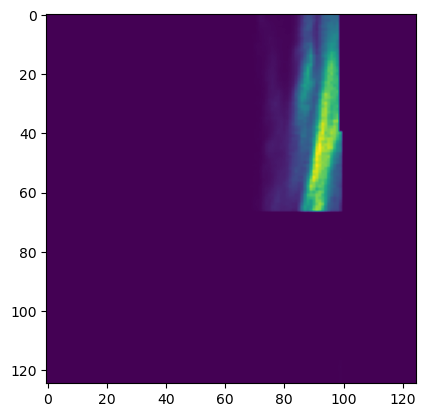

In [9]:
import matplotlib.pyplot as plt

i = 12500
plt.imshow(snowfall_profiles_2d[i:i+125,])